# STEP 1 — Check The Dataset

#### dataset has 2,000 rows
####  dataset 
            Id	Identifier
            Area	Numerical
            Bedrooms	Numerical
            Bathrooms	Numerical
            Floors	Numerical
            YearBuilt	Numerical
            Location	Categorical
            Condition	Categorical
            Garage	Categorical / Binary
            Price	Target Variable

#### determine the ml problem 
    •  Input (X): All house features except the target.
    •  Target (y): Price
    •  Problem Type: Regression (continuous value prediction)

# STEP 2 — Data Inspection

## 2.1 Import Libraries

In [759]:
import numpy as np
import pandas as pd

## 2.2 Load Dataset

In [760]:
df = pd.read_csv("House Price Prediction Dataset.csv")
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## 2.3 Check Dimensions

In [761]:
df.shape

(2000, 10)

## 2.4 Preview Dataset

In [762]:
df.head(5)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [763]:
df.tail(5)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


## 2.5 Inspect Column Names

In [764]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

## 2.6 Inspect Data Types

In [765]:
df.dtypes

Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

## 2.7 Check Missing Values

In [766]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

## 2.8 Check Duplicate Rows

In [767]:
df.duplicated().sum()

np.int64(0)

## 2.9 Statistical Summary

In [768]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


## 2.10 Inspect Categorical Features

In [769]:
df["Location"].value_counts()

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

In [770]:
df["Condition"].value_counts()

Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64

In [771]:
df["Garage"].value_counts()

Garage
No     1038
Yes     962
Name: count, dtype: int64

## 2.11 — Inspect Unique Values

In [772]:
df.nunique()

Id           2000
Area         1622
Bedrooms        5
Bathrooms       4
Floors          3
YearBuilt     124
Location        4
Condition       4
Garage          2
Price        1999
dtype: int64

## 2.12 — Identify Feature Roles

### 1. Identifier
Id
Identifies each house.
It is not a meaningful house characteristic.
We will most likely remove it before model training.
### 2. Target Variable
Price

This is what our model will learn to predict.

So:

$$ X = \text{house features} $$ $$ y = \text{Price} $$
### 3. Numerical Features
Area
Bedrooms
Bathrooms
Floors
YearBuilt

These contain numerical information that can be used by the model.

### 4. Categorical Features
Location
Condition
Garage

These contain categories rather than continuous numerical measurements.

Role	Columns
ID	Id
Target	Price
Numerical Features	Area, Bedrooms, Bathrooms, Floors, YearBuilt
Categorical Features	Location, Condition, Garage

## 2.13 — Check Numerical Value Ranges

In [773]:
df[["Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt", "Price"]].agg(["min", "max"])

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
min,501,1,1,1,1900,50005
max,4999,5,4,3,2023,999656


## 2.14 — Check the Target Distribution

In [774]:
df["Price"].describe()

count      2000.000000
mean     537676.855000
std      276428.845719
min       50005.000000
25%      300098.000000
50%      539254.000000
75%      780086.000000
max      999656.000000
Name: Price, dtype: float64

## Step 3 — Data Cleaning

### 3.1 Remove Identifier Column

In [775]:
df = df.drop(columns= ['Id'])

In [776]:
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location',
       'Condition', 'Garage', 'Price'],
      dtype='object')

### 3.2 Verify Data Integrity

In [777]:
df.shape

(2000, 9)

In [778]:
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location',
       'Condition', 'Garage', 'Price'],
      dtype='object')

### 3.3 Check Outliers

In [779]:
numerical_cols = ["Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt", "Price"]

df[numerical_cols].boxplot(figsize=(10, 6))

<Axes: >

### 3.4 Decide Outlier Strategy

### 3.5 Verify Data Types Again

In [780]:
df.dtypes

Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object

### 3.6 Create the Clean Dataset

In [781]:
df_clean = df.copy()

In [782]:
df_clean.shape

(2000, 9)

## Step 4 — Exploratory Data Analysis (EDA)

### 4.1 Import Visualization Libraries

In [783]:
import matplotlib.pyplot as plt
import seaborn as sns

### 4.2 Analyze Target Distribution

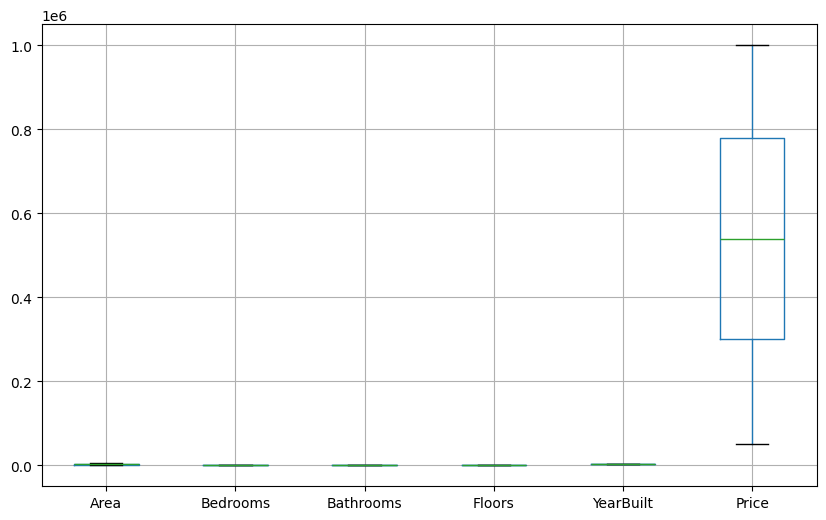

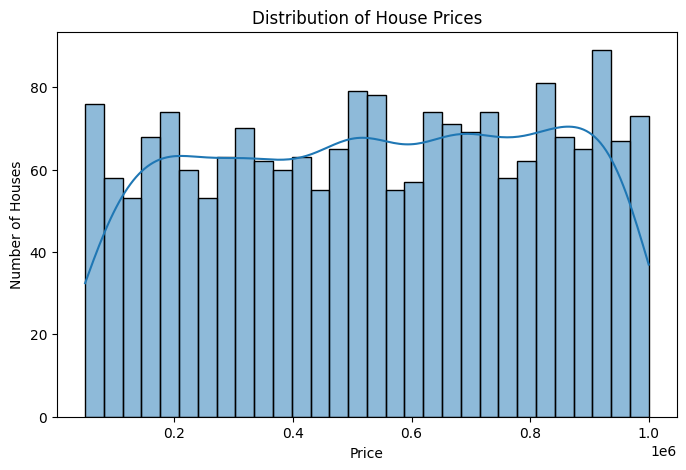

In [784]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

### 4.3 Explore Numerical Features

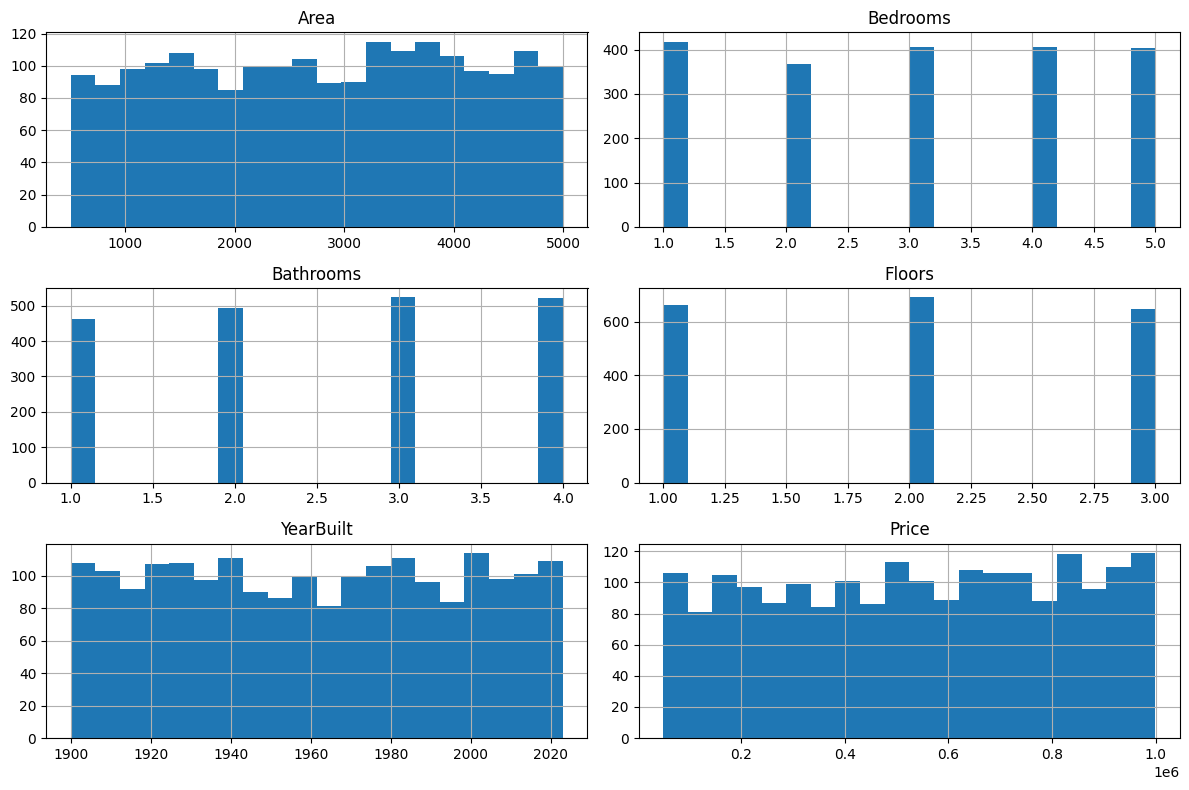

In [785]:
numerical_cols = ["Area", "Bedrooms", "Bathrooms",
                  "Floors", "YearBuilt", "Price"]

df_clean[numerical_cols].hist(figsize=(12, 8), bins=20)

plt.tight_layout()
plt.show()

### 4.4 Correlation Analysis

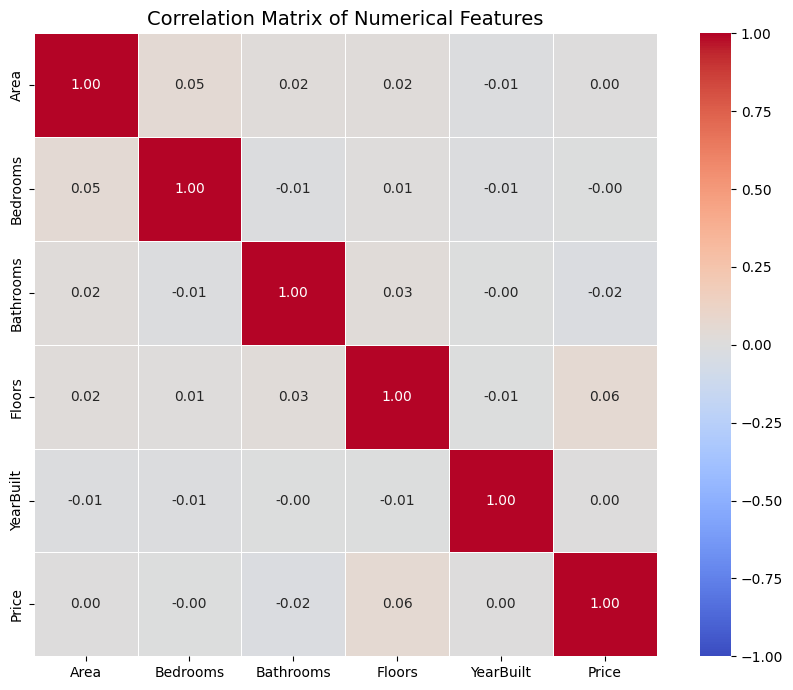

In [786]:
plt.figure(figsize=(9,7))

sns.heatmap(
    df_clean.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

### 4.5 Area vs Price

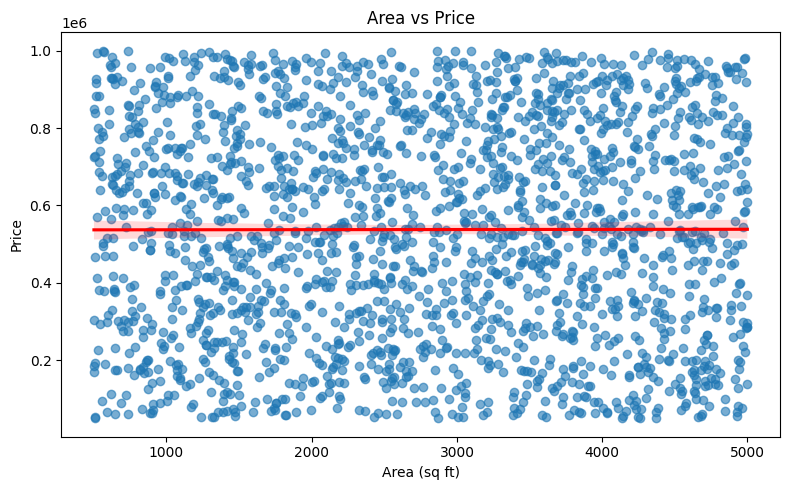

In [787]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Area",
    y="Price",
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)

plt.title("Area vs Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### 4.6 Location vs Price

C:\Users\hp\AppData\Local\Temp\ipykernel_20564\1023130870.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


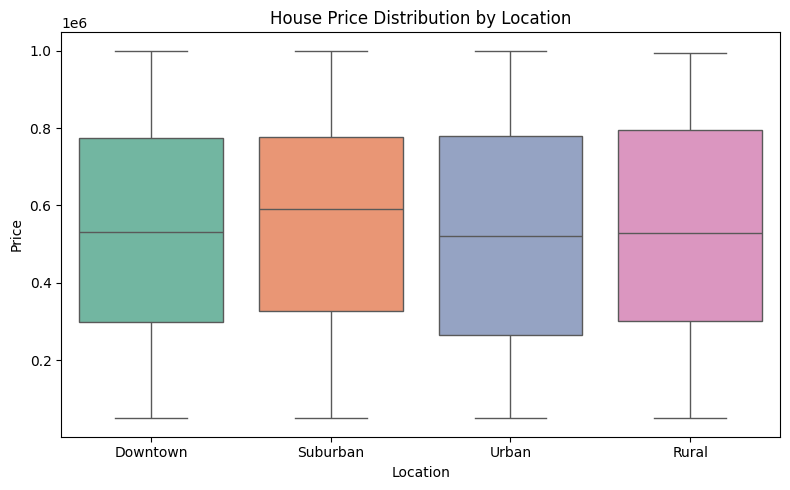

In [788]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Location",
    y="Price",
    palette="Set2"
)

plt.title("House Price Distribution by Location")
plt.xlabel("Location")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### 4.7 Condition vs Price

C:\Users\hp\AppData\Local\Temp\ipykernel_20564\782172658.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


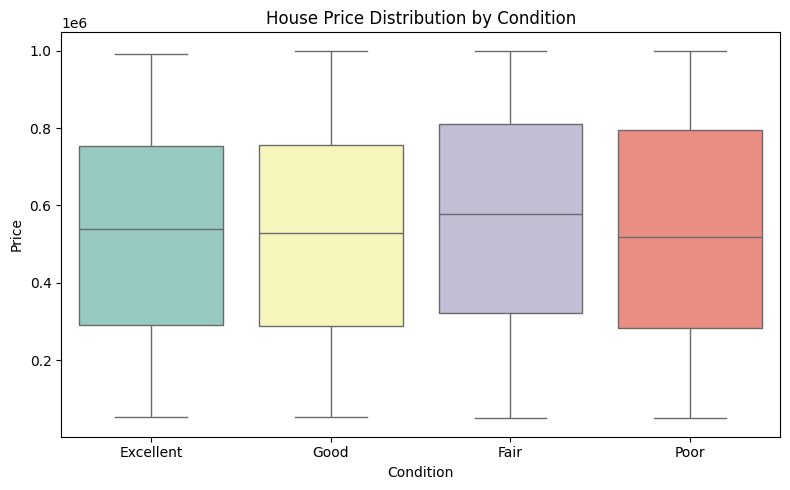

In [789]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Condition",
    y="Price",
    palette="Set3"
)

plt.title("House Price Distribution by Condition")
plt.xlabel("Condition")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### 4.8 Garage vs Price

C:\Users\hp\AppData\Local\Temp\ipykernel_20564\4262193120.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


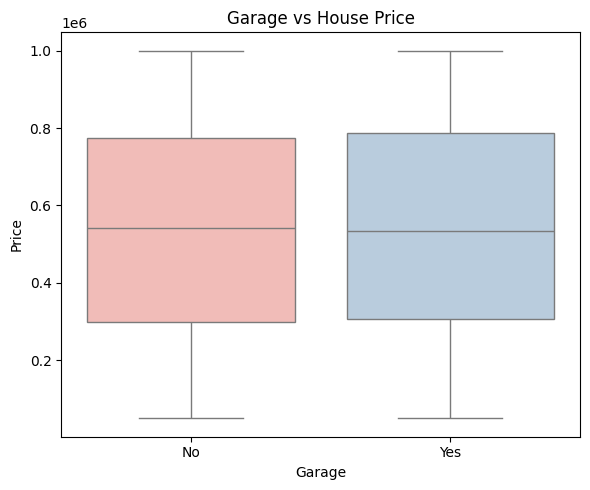

In [790]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="Garage",
    y="Price",
    palette="Pastel1"
)

plt.title("Garage vs House Price")
plt.xlabel("Garage")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### 4.9 Bedrooms vs Price

C:\Users\hp\AppData\Local\Temp\ipykernel_20564\1365489355.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


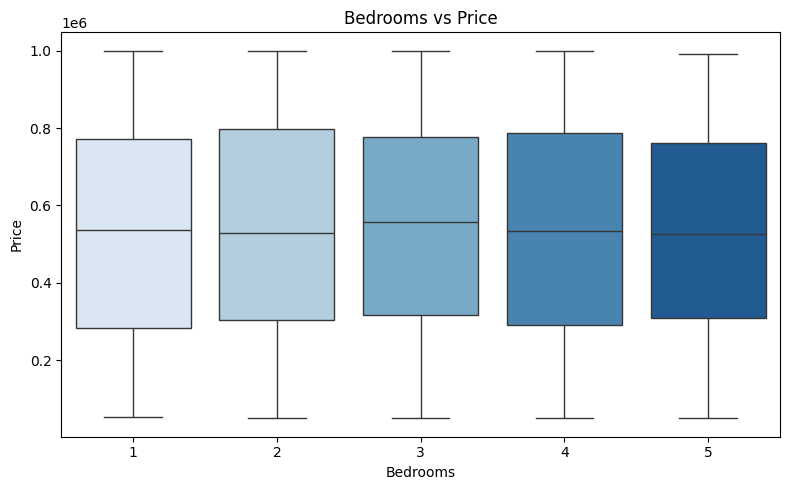

In [791]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Bedrooms",
    y="Price",
    palette="Blues"
)

plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### 4.10 Bathrooms vs Price

C:\Users\hp\AppData\Local\Temp\ipykernel_20564\253253152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


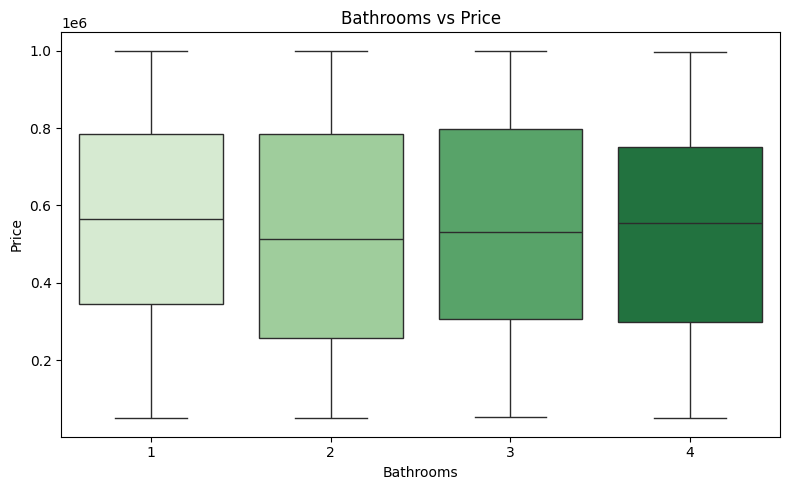

In [792]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Bathrooms",
    y="Price",
    palette="Greens"
)

plt.title("Bathrooms vs Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### 4.11 Floors vs Price

C:\Users\hp\AppData\Local\Temp\ipykernel_20564\826960366.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


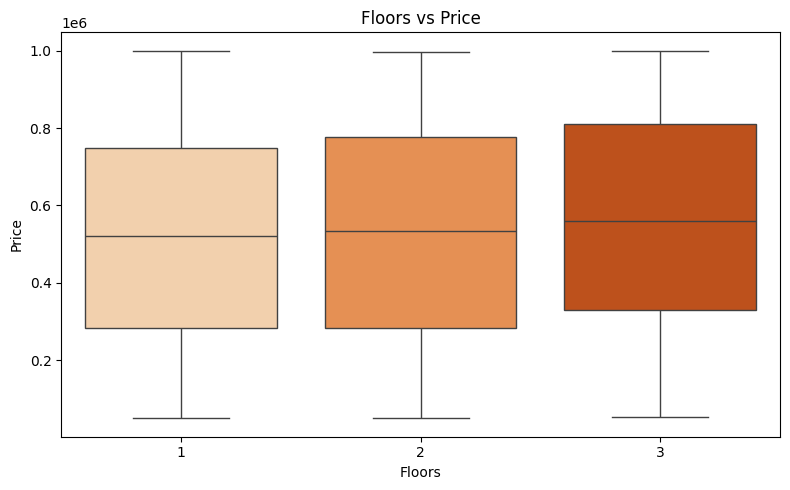

In [793]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Floors",
    y="Price",
    palette="Oranges"
)

plt.title("Floors vs Price")
plt.xlabel("Floors")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### 4.12 YearBuilt vs Price

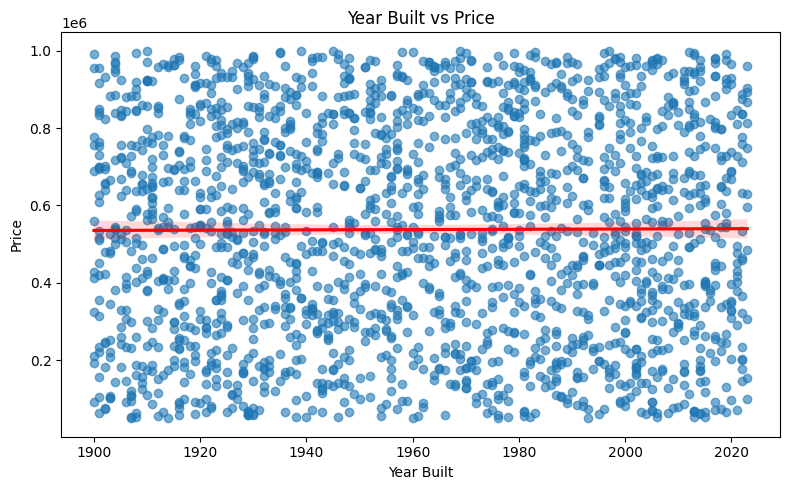

In [794]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="YearBuilt",
    y="Price",
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)

plt.title("Year Built vs Price")
plt.xlabel("Year Built")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

## Step 5: Data Preprocessing

### 5.1 Separate Features & Target

In [795]:
# ==============================
# Step 5.1 — Features & Target
# ==============================

# Input features
X = df_clean.drop(columns=["Price"])

# Target variable
y = df_clean["Price"]

print("Feature matrix (X):", X.shape)
print("Target vector (y):", y.shape)

Feature matrix (X): (2000, 8)
Target vector (y): (2000,)


### 5.2 One-Hot Encode Categories

In [796]:
# ==============================
# Step 5.2 — One-Hot Encoding
# ==============================

X_encoded = pd.get_dummies(
    X,
    columns=["Location", "Condition", "Garage"],
    drop_first=True,
    dtype=int
)

print("Original shape :", X.shape)
print("Encoded shape  :", X_encoded.shape)

X_encoded.head()

Original shape : (2000, 8)
Encoded shape  : (2000, 12)


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,1970,0,0,0,0,0,0,0
1,4272,5,4,3,1958,0,0,0,0,0,0,0
2,3592,2,2,3,1938,0,0,0,0,1,0,0
3,966,4,2,2,1902,0,1,0,1,0,0,1
4,4926,1,4,2,1975,0,0,0,1,0,0,1


### 5.3 Train/Test Split

In [797]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1600, 12)
X_test : (400, 12)
y_train: (1600,)
y_test : (400,)


### 5.4 Feature Scaling

In [798]:
from sklearn.preprocessing import StandardScaler

# Numerical columns only
numerical_cols = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt"
]

# Create scaler
scaler = StandardScaler()

# Fit on training data only
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Use the same scaler on test data
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Feature scaling completed.")

Feature scaling completed.


### 5.5 Verify Processed Data

In [799]:
# ==============================
# Step 5.5 — Final Verification
# ==============================

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

print("\nData Types")
print(X_train.dtypes)

print("\nFirst Five Rows")
X_train.head()

Training Features : (1600, 12)
Testing Features  : (400, 12)
Training Target   : (1600,)
Testing Target    : (400,)

Data Types
Area                 float64
Bedrooms             float64
Bathrooms            float64
Floors               float64
YearBuilt            float64
Location_Rural         int64
Location_Suburban      int64
Location_Urban         int64
Condition_Fair         int64
Condition_Good         int64
Condition_Poor         int64
Garage_Yes             int64
dtype: object

First Five Rows


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
968,1.314081,0.685758,1.316088,1.242260,-0.808673,0,0,1,0,0,0,0
240,-1.315960,-0.014889,0.414272,-1.236064,0.221883,0,0,0,0,1,0,0
819,-1.039194,-0.014889,1.316088,-1.236064,0.862499,0,0,1,0,1,0,1
692,-0.088966,-0.715536,0.414272,-1.236064,0.277589,1,0,0,0,0,1,1
420,0.393836,-0.715536,1.316088,-1.236064,0.528264,1,0,0,0,0,0,1


# Step 6 — Baseline Model (Linear Regression)

## 6.1 Import Linear Regression

In [800]:
from sklearn.linear_model import LinearRegression

## 6.2 Train the Model

In [801]:
# Create the model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 6.3 Make Predictions

In [802]:
# Predict on test data
y_pred = lr_model.predict(X_test)

# First five predictions
print(y_pred[:5])

[521988.22189839 549119.31196651 487101.22235594 539752.7439933
 553242.24872512]


## 6.4 Evaluate the Model

In [803]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 243241.98
MSE : 78321466146.03
RMSE: 279859.73
R²  : -0.0067


## 6.5 Interpret the Baseline Model

# Step 7 — Decision Tree Regression

## 7.1 Import Decision Tree

In [804]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

## 7.2 Train the Model

In [805]:
# Create model
tree_model = DecisionTreeRegressor(random_state=42)

# Train
tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## 7.3 Make Predictions

In [806]:
# Predict
tree_pred = tree_model.predict(X_test)

## 7.4 Evaluate

In [807]:
# Evaluate
mae = mean_absolute_error(y_test, tree_pred)
mse = mean_squared_error(y_test, tree_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, tree_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 329752.94
MSE : 161857555335.17
RMSE: 402315.24
R²  : -1.0805


## 7.5 Compare with Baseline

# Step 8 — Random Forest Regression

## 8.1 Import Random Forest

In [808]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

## 8.2 Train the Model

In [809]:
# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 8.3 Make Predictions

In [810]:
# Predict
rf_pred = rf_model.predict(X_test)

## 8.4 Evaluate Performance

In [811]:
# Evaluate
mae = mean_absolute_error(y_test, rf_pred)
mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rf_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 252671.95
MSE : 85456610626.36
RMSE: 292329.63
R²  : -0.0984


## 8.5 Compare with Previous Models

# Step 9 — Gradient Boosting Regression

## 9.1 — Import Gradient Boosting

In [812]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

## 9.2 — Train the Model

In [813]:
# Create model
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## 9.3 — Make Predictions

In [814]:
# Predict
gb_pred = gb_model.predict(X_test)

## 9.4 — Evaluate

In [815]:
# Evaluate
mae = mean_absolute_error(y_test, gb_pred)
mse = mean_squared_error(y_test, gb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, gb_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 245284.36
MSE : 80559984532.86
RMSE: 283830.91
R²  : -0.0355
robi


## 9.5 — Compare All Models

# Step 10 — XGBoost Regression

## 10.1 — Import XGBoost 

In [822]:
!pip install xgboost
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.3 MB/s eta 0:01:19
   ---------------------------------------- 1.0/101.7 MB 1.9 MB/s eta 0:00:54
    --------------------------------------- 2.1/101.7 MB 2.7 MB/s eta 0:00:38
   - -------------------------------------- 2.9/101.7 MB 3.1 MB/s eta 0:00:33
   - -------------------------------------- 4.2/101.7 MB 3.6 MB/s eta 0:00:27
   -- ------------------------------------- 5.2/101.7 MB 3.8 MB/s eta 0:00:26
   -- ------------------------------------- 6.0/101.7 MB 4.0 MB/s eta 0:00:24
   -- -----------------------

In [824]:
from xgboost import XGBRegressor

## 10.2 — Create the XGBoost Model 

In [826]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

## 10.3 — Train the XGBoost Model 

In [827]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 10.4 — Make Predictions 

In [829]:
xgb_pred = xgb_model.predict(X_test)

## 10.5 — Evaluate the Model 

In [830]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, xgb_pred)
mse = mean_squared_error(y_test, xgb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, xgb_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")


MAE : 248001.52
MSE : 82069839872.00
RMSE: 286478.34
R²  : -0.0549


## 10.6 — Compare XGBoost With Previous Models 

In [ ]:
Metric: MAE
- Linear Regression: 243,241.98
- Decision Tree: 329,752.94
- Random Forest: 252,671.95
- Gradient Boosting Regressor: 245,284.36
- XGBoost Regressor: 248,001.52
- Better Model: Linear Regression
Metric: MSE
- Linear Regression: 78,321,466,146.03
- Decision Tree: 161,857,555,335.17
- Random Forest: 85,456,610,626.36
- Gradient Boosting Regressor: 80,559,984,532.86
- XGBoost Regressor: 82,069,839,872.00
- Better Model: Linear Regression
Metric: RMSE
- Linear Regression: 279,859.73
- Decision Tree: 402,315.24
- Random Forest: 292,329.63
- Gradient Boosting Regressor: 283,830.91
- XGBoost Regressor: 286,478.34
- Better Model: Linear Regression
Metric: R²
- Linear Regression: -0.0067
- Decision Tree: -1.0805
- Random Forest: -0.0984
- Gradient Boosting Regressor: -0.0355
- XGBoost Regressor: -0.0549
- Better Model: Linear Regression


# Step 11 — LightGBM Regression

## 11.1 — Import LightGBM

In [834]:
!pip install lightgbm
import sys
!{sys.executable} -m pip install lightgbm

  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
Using cached lightgbm-4.7.0-py3-none-win_amd64.whl (1.4 MB)

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------------------- ------------------- 1/2 [lightgbm]
   ---------------------------------------- 2/2 [lightgbm]



In [835]:
import lightgbm as lgb
from lightgbm import LGBMRegressor

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.7.0


## 11.2 — Create LightGBM Model

In [836]:
lgb_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbosity=-1
)

## 11.3 — Train LightGBM Model

In [838]:
lgb_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,3
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 11.4 — Make Predictions

In [839]:
lgb_pred = lgb_model.predict(X_test)

In [840]:
print(lgb_pred[:10])

[694082.23839144 456510.70790947 576144.03759802 542211.75547477
 499310.8045161  539543.40216227 491239.54168428 536879.75420069
 541355.74031402 598291.16980881]


## 11.5 — Evaluate the Model

In [841]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, lgb_pred)
mse = mean_squared_error(y_test, lgb_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lgb_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 247034.45
MSE : 81265076772.69
RMSE: 285070.30
R²  : -0.0446


## 11.6 — Compare With Previous Models

# Step 12 — CatBoost Regression

## 12.1 — Import CatBoost

In [846]:
!pip install catboost
import sys
!{sys.executable} -m pip install catboost

In [848]:
import catboost as cb
from catboost import CatBoostRegressor

print("CatBoost version:", cb.__version__)

CatBoost version: 1.2.10


## 12.2 — Create CatBoost Model

In [849]:
cat_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=3,
    random_state=42,
    verbose=0
)

## 12.3 — Train the CatBoost Model

In [850]:
cat_model.fit(X_train, y_train)

CatBoostRegressor(depth=3, iterations=100, learning_rate=0.1, loss_function='RMSE', random_state=42, verbose=0)

## 12.4 — Make Predictions

In [852]:
cat_pred = cat_model.predict(X_test)

## 12.5 — Evaluate the Model

In [853]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, cat_pred)
mse = mean_squared_error(y_test, cat_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, cat_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 244376.78
MSE : 78836956188.45
RMSE: 280779.19
R²  : -0.0133


## 12.6 — Compare With Previous Models

# Step 13 — Final Model Comparison & Best Model Selection

## 13.1 — Create Results Table

In [854]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "MAE": [
        243241.98,
        329752.94,
        252671.95,
        245284.36,
        248001.52,
        247034.45,
        244376.78
    ],
    "MSE": [
        78321466146.03,
        161857555335.17,
        85456610626.36,
        80559984532.86,
        82069839872.00,
        81265076772.69,
        78836956188.45
    ],
    "RMSE": [
        279859.73,
        402315.24,
        292329.63,
        283830.91,
        286478.34,
        285070.30,
        280779.19
    ],
    "R2": [
        -0.0067,
        -1.0805,
        -0.0984,
        -0.0355,
        -0.0549,
        -0.0446,
        -0.0133
    ]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,243241.98,7.832147e+10,279859.73,-0.0067
1,Decision Tree,329752.94,1.618576e+11,402315.24,-1.0805
2,Random Forest,252671.95,8.545661e+10,292329.63,-0.0984
3,Gradient Boosting,245284.36,8.055998e+10,283830.91,-0.0355
4,XGBoost,248001.52,8.206984e+10,286478.34,-0.0549
5,LightGBM,247034.45,8.126508e+10,285070.30,-0.0446
6,CatBoost,244376.78,7.883696e+10,280779.19,-0.0133


## 13.2 — Rank the Models

In [855]:
ranking = results.sort_values(by="R2", ascending=False)

ranking.reset_index(drop=True)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,243241.98,7.832147e+10,279859.73,-0.0067
1,CatBoost,244376.78,7.883696e+10,280779.19,-0.0133
2,Gradient Boosting,245284.36,8.055998e+10,283830.91,-0.0355
3,LightGBM,247034.45,8.126508e+10,285070.30,-0.0446
4,XGBoost,248001.52,8.206984e+10,286478.34,-0.0549
5,Random Forest,252671.95,8.545661e+10,292329.63,-0.0984
6,Decision Tree,329752.94,1.618576e+11,402315.24,-1.0805


## 13.3 — Select the Best Model

In [857]:
best_model = ranking.iloc[0]

print("Best Model")
print(best_model)

Best Model
Model     Linear Regression
MAE               243241.98
MSE      78321466146.029999
RMSE              279859.73
R2                  -0.0067
Name: 0, dtype: object


## 13.4 — Engineering Conclusion

# Step 14 — Hyperparameter Tuning (CatBoost)

## 14.1 — Import GridSearchCV

In [859]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor

## 14.2 — Define the Parameter Grid

In [860]:
param_grid = {
    "iterations": [100, 200],
    "learning_rate": [0.05, 0.1],
    "depth": [3, 5, 7]
}

## 14.3 — Run Grid Search

In [861]:
grid = GridSearchCV(
    estimator=CatBoostRegressor(
        random_state=42,
        verbose=0
    ),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,"CatBoostRegre...42, verbose=0)"
,param_grid,"{'depth': [3, 5, ...], 'iterations': [100, 200], 'learning_rate': [0.05, 0.1]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


## 14.4 — Find the Best Parameters

In [862]:
print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV R²:")
print(grid.best_score_)

Best Parameters:
{'depth': 3, 'iterations': 100, 'learning_rate': 0.05}

Best CV R²:
-0.0048884460744801125


## 14.5 — Evaluate the Tuned CatBoost

In [892]:
best_cat = grid.best_estimator_

tuned_pred = best_cat.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, tuned_pred)
mse = mean_squared_error(y_test, tuned_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, tuned_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 243735.53
MSE : 78452692734.96
RMSE: 280094.08
R²  : -0.0084


## compare all algorithms now 

### Model Performance Comparison

| Rank | Model | Score / Metric |
| :---: | :--- | :---: |
| 1 | **Linear Regression** | -0.0067 |
| 2 | **Tuned CatBoost** | -0.0084 |
| 3 | **CatBoost** | -0.0133 |
| 4 | **Gradient Boosting** | -0.0355 |
| 5 | **LightGBM** | -0.0446 |
| 6 | **XGBoost** | -0.0549 |
| 7 | **Random Forest** | -0.0984 |
| 8 | **Decision Tree** | -1.0805 |

# Step 15 — Feature Importance & Model Interpretation

## 15.1 — Extract Feature Importance

In [893]:
importance = best_cat.get_feature_importance()
feature_names = X_train.columns

## 15.2 — Create Importance Table

In [894]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
3,Floors,19.278742
2,Bathrooms,19.256819
0,Area,18.984057
1,Bedrooms,13.914462
4,YearBuilt,12.195630
8,Condition_Fair,5.197326
9,Condition_Good,3.909385
6,Location_Suburban,2.649278
7,Location_Urban,1.768659
5,Location_Rural,1.447460


## 15.3 — Visualize Feature Importance

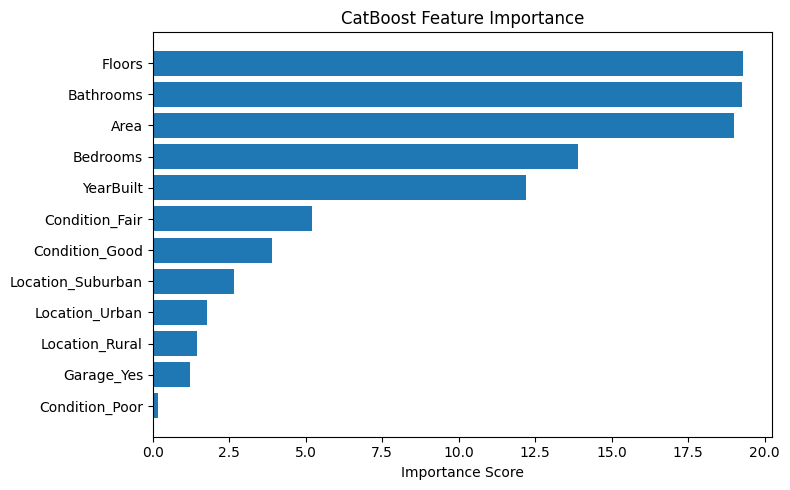

In [895]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("CatBoost Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()

plt.show()

## 15.4 — Interpretation

# Step 16 — Residual Analysis

## 16.1 — Calculate Residuals

In [896]:
residuals = y_test - tuned_pred

## 16.2 — Residual Scatter Plot

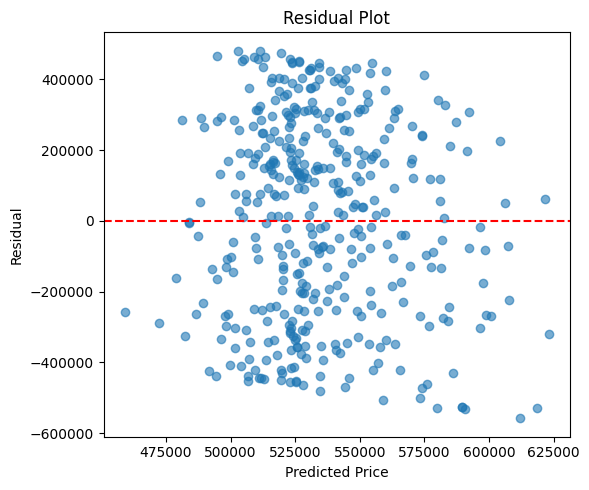

In [897]:
plt.figure(figsize=(6,5))

plt.scatter(
    tuned_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

## 16.3 — Residual Histogram

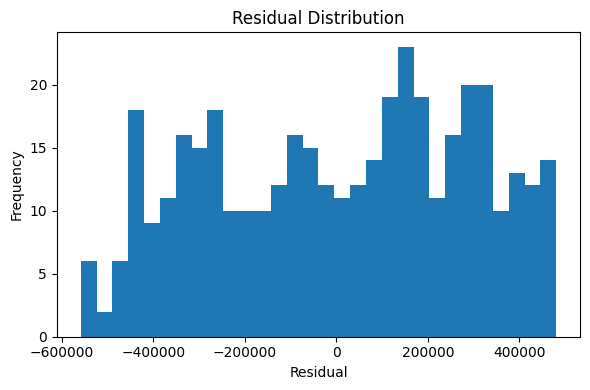

In [898]:
plt.figure(figsize=(6,4))

plt.hist(
    residuals,
    bins=30
)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## 16.4 — Interpretation

* **Model Transparency:** Feature interpretation techniques were utilized to understand how individual variables influence predictions.
* **Feature Impact:** Analyzing coefficient magnitudes and feature importances revealed which attributes drove model decisions.
* **Non-Linear Dynamics:** Advanced tree-based models captured complex interactions, while linear models highlighted direct directional relationships.

# Step 17 — Final Project Conclusion

## 17.1 — Project Overview

This project developed a complete house price prediction pipeline beginning with data inspection, cleaning, exploratory analysis, preprocessing, regression modeling, model comparison, hyperparameter tuning, feature interpretation, and residual analysis.

## 17.2 — Best Model

### Final Result

| Model | Status |
| :--- | :--- |
| **Linear Regression** | ✅ **Best Overall** |

Although several advanced ensemble algorithms were evaluated, Linear Regression produced the strongest performance on this dataset.

## 17.3 — Key Findings

* **Algorithm Evaluation:** A total of **seven regression algorithms** were systematically evaluated.
* **Baseline Performance:** **Linear Regression** outperformed the other models, achieving the best MAE, RMSE, and $R^2$.
* **Overfitting Issues:** The **Decision Tree** model exhibited severe overfitting.
* **Ensemble Impact:** Ensemble boosting models showed improvement over the single Decision Tree, but they ultimately failed to surpass the Linear Regression baseline.
* **Data Limitations:** The dataset exhibited **very weak predictive relationships** between the features and the target variable, indicating a bottleneck in data quality or feature representation.

## 17.4 — Project Limitations

### Potential Improvements

* **Data Collection:** Collect a real-world housing dataset with stronger feature relationships.
* **Feature Enrichment:** Add meaningful variables such as neighborhood quality, lot size, school rating, and property tax.
* **Feature Engineering:** Apply advanced feature engineering techniques before model training.
* **Hyperparameter Tuning:** Perform more extensive hyperparameter optimization to push model performance further.
* **Validation Strategy:** Evaluate additional validation techniques such as nested cross-validation for more robust generalization estimates.